# Compute the CTE
In this notebook we deal with the calculation of the coefficient of thermal expansion (CTE). Two approaches are available:
- a) Volume-temperature approach
- b) Enthalpy-volume fluctuations approach

Both approaches have been implemented in separate workflows. For both approaches we briefly cover the theoretical background, highlight the most important input parameters and general procedure of the workflow, and mention their caveats and things to consider. Furthermore, a short test simulation based on a small system (SiO2 glass with 300 atoms) will showcase the workflows in action (they are not meant for converged results!). Additionally, we will provide pre-computed results obtained from more reasonable input settings to illustrate a simple analysis of the results.

Before we go into details, we import the necessary libraries and functions to be able to execute all code cells in this notebook.

In [1]:
from executorlib import SingleNodeExecutor
import numpy as np
import json
from scipy import stats
from ase.io import read as ASEread
import matplotlib.pyplot as plt

from amorphouspy import (
    cte_from_fluctuations_simulation,
    temperature_scan_simulation,
    generate_potential,
)

import pandas as pd

pd.set_option("display.float_format", "{:.2e}".format)  # show all numbers in scientific notation

In [2]:
def linear_fit(x, y):
    """Perform a linear fit and return the fit function, slope and R2 value."""
    result = stats.linregress(x, y)
    linear_fit = np.poly1d([result.slope, result.intercept])
    slope = result.slope
    R2 = result.rvalue**2
    return linear_fit, slope, R2

# a) Volume-temperature approach
## Theory
Conventionally, CTEs are computed from structural changes as function of temperature, e.g. for the volumetric CTE (often $\alpha$ is used as symbol for the CTE):
$$
\alpha_V = \frac{1}{V_0}\frac{dV}{dT}\quad\quad,
$$
where $V$ and $T$ are volumen and temperature. $V_0$ is the reference volume. For the linear CTE, the same formula applies but $V$ and $V_0$ need to be replaced by the relevant cell dimension (e.g., $c$ and $c_0$ for the CTE along the $c$-axis). To be able to apply this formula, simulations at different temperatures need to be performed and the average volume (or cell dimensions) at each temperature need to be recorded. This is implemented in the workflow `temperature_scan_simulation`. However, this workflow only returns the average volume and cell dimensions (along with other thermodynamic properties) at each temperature step. The actual CTE calculation is not implemented in the workflow, because it is not easy to anticipate the actual dependence of the CTE and what model a user would like to apply. Typical analysis can involve:
- "CTE20-300": Only the two temperatures of 20°C and 300°C and the corresponding structural data are used to calculate the CTE. It ignores any non-linear behavior but might be sufficient for a first estimate of the CTE or for materials with very linear CTE behavior over this temperature range.
- "Linear fit": A linear fit of the volume (or cell dimension) vs. temperature data is performed and the CTE is obtained from the slope of this fit. Most useful if the CTE is relatively constant over the temperature range of interest.
- "Polynomial fit": A higher order polynomial fit of the volume (or cell dimension) vs. temperature data is performed and the CTE is obtained from the derivative of this fit at a given temperature. This is useful for materials with non-linear CTE behavior, but requires more data points to perform a robust fit and can be more sensitive to noise in the data.


## Details on `temperature_scan_simulation` workflow
The most important input parameters for this workflow are:
- List of temperatures (in units of Kelvin) at which the simulations should be performed
- Number of equilibration and production steps that will be perfromed at every temperature

The general procedure of the workflow is as follows:
1) Short NVT simulation to equilibrate temperature for 10k steps (hardcoded)
2) NPT equilibration run with user-specified number of steps to equilibrate the volume and cell dimensions at the given temperature
3) NPT production run, where the average volume and cell dimensions (along with other thermodynamic properties) are recorded.
4) Advance to the next temperature and repeat the procedure starting from step 1 until all temperatures have been covered.

How the output of the workflow is structured is shown further below in the example simulation.

## Caveats and things to consider
- Systems with very low CTEs might require a wider temperature window or longer simulation times to obtain reliable results that can be distinguished from noise.
- This workflow works especially well for crystalline systems that have defined equilibrium lattice constants.
- Care is advisable for glasses that are prepared with very high quenching rates: This is because the equilibrium volume of glasses is an ill-defined property that depends on thermal history of the material. If the glass structure is not well relaxed, relaxation processes can be activated during the temperature scan and lead to a drift of the volume (typically shrinking). If this volume change due to relaxation is of similar magnitude as the thermal expansion, the CTE calculation can yield unphysical results (e.g., apparent negative CTEs). To mitigate this, one can e.g. reduce the simulation time at each temperature step (but keep it long enough to get good averages for the structural properties), or prepare the glass structure with more moderate quenching rates to allow for more relaxation already during glass formation. 
- To test if relaxation processes are affecting the results, one can also perform a reverse temperature scan to test the hystersis of the structural parameters. 
- The higher the CTE of the material, the less impact is expected from the relaxation. Glasses with CTEs > 10e-6 K$^{-1}$ (e.g., many oxide glasses) are typically not problematic.


## Showcase: Temperature-volume approach
We start from a small, previously generated SiO2 glass with 300 atoms that we use as starting structure for our simulation. The structure has been saved in xyz-format and can be read with the ASE (Atomic Simulation Environment) package:

In [3]:
structure_glass_small = ASEread("data/SiO2_glass_300_atoms.xyz")
structure_glass_small

Atoms(symbols='O200Si100', pbc=True, cell=[[16.48757572410817, 3.0287185254343006e-15, 3.028718525434301e-15], [-2.019145683487156e-15, 16.487575723, 3.0287185252307334e-15], [-2.0191456834871554e-15, -2.019145683487156e-15, 16.487575723]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)

If external structures are used, the potential needs to be set up manually by defining an atoms dictionary. The only info needed is the atom types. If structures are set up from scratch (see meltquenching notebooks), such a dictionary is automatically generated. Here, we use the Pedone PMMCS potential for SiO2, which is implemented by setting `potential="pmmcs"` in the input parameters of the workflow. In this notebook, we rely on the [executorlib](https://executorlib.readthedocs.io/en/latest/README.html) package to execute and handle the submission and resource allocation when running the or workflows. Alternative job management packages are [pyiron](https://pyiron.readthedocs.io/en/latest/) or [aiida](https://www.aiida.net/). 

WIth `executorlib` it is good habit to wrap the actual submission in a context manager block (`with ...:`) to guarantee that all processes are properly managed and ressources are freed once the block is exited. The `SingleNodeExecutor` will make use of the resources of your local machine. Its `submit()` method expects the function (or workflow) that should be executed as the first argument, followed by the input parameters that function (or workflow) requires.


In [4]:
# Custom atoms dictionary - must be alphabetically ordered
custom_atoms_dict_Si_O = {"atoms": [{"element": "O"}, {"element": "Si"}]}

# Generating the potential
with SingleNodeExecutor() as exe:
    generated_potential_Si_O = exe.submit(
        generate_potential,  # function to execute
        atoms_dict=custom_atoms_dict_Si_O,  # input parameters for the function
        potential_type="pmmcs",  # input parameters for the function
    ).result()

After executing the above command, we can inspect the potential and find that it has been correctly set up:

In [5]:
generated_potential_Si_O

,Name,Filename,Model,Species,Config
0,PMMCS,[],PMMCS,"[O, Si]","[# A. Pedone et.al., JPCB (2006), https://doi...."


Note again that the following simulation is designed as a showcase to finish fast on few resources - the results should not be treated as something reasonable.

Both the structure and the potential now enter as input to the `temperature_scan_simulation` workflow. Additionally, we specify the `temperature` list to cover 250 K, 300 K and 350 K. Because we use the `pyiron` interface to LAMMPS as the backend to run the actual simulations, we work with the corresponding units and need to specify the `pressure` in units of GPa (1 bar = 0.0001 GPa). The `timestep` is in units of femtoseconds (fs), and 1 fs timesteps can be used for many systems (e.g., very high temperatures or systems containing H might require smaller timesteps, and systems with only heavy ions could use larger timesteps). 

The number of `equilibration_steps` and `production_steps` is set to 20k steps each (note again that this is preceeded with a hard-coded NVT simulation with 10k timesteps for every temperature). The dump frequency `n_dump` that controls how often the structure is written to file is set to 20k to avoid unnecessary I/O and because we are not interested in analyzing structural aspects for this showcase. The log frequency `n_log` is set to every 10th time step to enable a valid averaging without using unnecessarily verbose output. 

The `server_kwargs` dictionary can be used to specify server parameters for the execution of the workflow, e.g., if you want to run the workflow on a cluster instead of your local machine and to chose the number of cores. Here, we specify that we want to use 4 cores for the local execution (note that this is not necessarily the optimal choice for this small system and short simulation time, but it serves well for demonstration purposes). `aniso` is set to `True` to allow for anisotropic cell changes, which can be important to analyze anisotropic effects. If `aniso` is set to `False`, only isotropic cell changes are allowed. The `seed` serves for the initialization of atomic velocities. Repeating the same simulation with a different seed should yield similar results, but can be used to test the robustness of the results with respect to the stochastic nature of the MD simulations.

In [6]:
### Running the CTE simulation locally with 4 cores for demonstration purposes (~1.5 min runtime)
server_kwargs = {"cores": 4}

with SingleNodeExecutor() as exe:
    cte_results_T_V_showcase = exe.submit(
        temperature_scan_simulation,
        structure=structure_glass_small,
        potential=generated_potential_Si_O,
        temperature=[250, 300, 350],
        pressure=1e-4,
        timestep=1.0,
        equilibration_steps=20_000,
        production_steps=20_000,
        n_dump=20_000,
        n_log=10,
        server_kwargs=server_kwargs,
        aniso=True,
        seed=12345,
    ).result()

/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


Warnings above concerning the unit conversion of quantity Lx/Ly/Lz can be ignored. 

The result of the workflow is a nested dictionary as shown below. Its only main key is `data` containing another dictionary that holds several structural and thermodynamic properties:
- `run_index`: The order of which the data has been collected, starting from 1
- `steps`: The number of steps used for each production run. Equals the input parameter `production_steps`.
- `T`: The temperatures at which the simulations have been performed. Here, the actual averages of the production runs are listed, not the user-specified temperatures.
- `E_tot`: The average total energy at each production run.
- `ptot`: The average pressure at each production run.
- `pxx`, `pyy`, `pzz`: The average pressure components at each production run.
- `V`: The average volume at each production run.
- `Lx`, `Ly`, `Lz`: The average cell dimensions at each production run.
- `structure_final`: The final structure (ASE atoms object) at the end of the last production run. Helpful to inspect the final structure or to used it as starting structure for further simulations.

In [7]:
cte_results_T_V_showcase

{'data': {'run_index': array([1., 2., 3.]),
  'steps': array([20000., 20000., 20000.]),
  'T': array([252.03754789, 300.5879614 , 350.34295188]),
  'E_tot': array([-5302.13103968, -5298.33478466, -5294.43138221]),
  'ptot': array([ 0.00033433,  0.00015765, -0.00026151]),
  'pxx': array([-0.00016789,  0.00086213,  0.00154342]),
  'pyy': array([ 0.00023191, -0.00047327, -0.00096289]),
  'pzz': array([ 9.38961770e-04,  8.41095892e-05, -1.36505836e-03]),
  'V': array([4471.93763068, 4472.97298996, 4475.27629965]),
  'Lx': array([16.23891923, 16.24097672, 16.23676336]),
  'Ly': array([16.96698904, 16.96798048, 16.97538257]),
  'Lz': array([16.2306478 , 16.23141868, 16.2370178 ]),
  'structure_final': Atoms(symbols='O200Si100', pbc=True, cell=[[16.300725178252474, 6.9869208196646436e-15, 6.986920819664647e-15], [-7.293903974285101e-15, 17.016927374753266, 7.293903974285096e-15], [-6.9383787342119966e-15, -6.938378734212001e-15, 16.1874748330767]], id=..., indices=..., initial_charges=..., ma

As an example, we plot the volume and the individual cell dimensions versus temperature and use it to compute the volumetric and the linear CTEs by applying a linear fit to the data. Because of the small system size and short simulation time, the data will be quite noisy. Also, true isotropy in amorphous systems can only be achieved if the system is size is considerably smaller. Therefore, it is not surprising if unsystematic changes of individual box dimensions are observed. For such cases, the volume tends to be better behaved and the volumetric CTE is often more reliable than the linear CTEs.

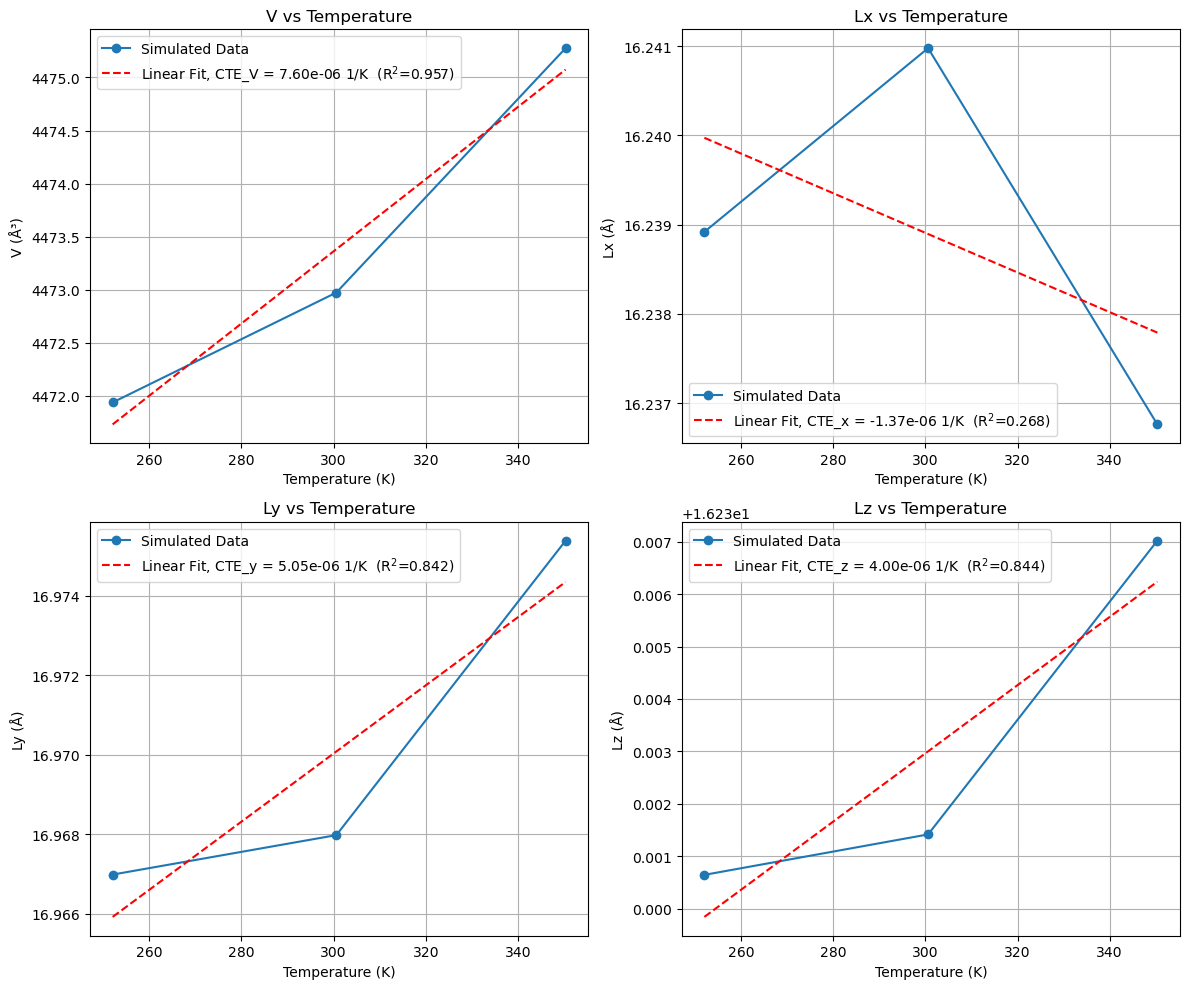

In [8]:
# Set up the plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Go through structural data and plot it + perform linear fit and compute CTE based on the slope of the linear fit
for ax, datakey in zip([ax1, ax2, ax3, ax4], ["V", "Lx", "Ly", "Lz"]):
    # Perform linear fit and compute CTE based on the slope of the linear fit
    linear_fit_func, slope, R2 = linear_fit(
        cte_results_T_V_showcase["data"]["T"], cte_results_T_V_showcase["data"][datakey]
    )
    ref_value = cte_results_T_V_showcase["data"][datakey][
        1
    ]  # If we are interested in the CTE at 300 K, we use the corresponding value at 300 K as prop0
    CTE = 1 / ref_value * slope

    # Plot actual data and linear fit
    ax.plot(
        cte_results_T_V_showcase["data"]["T"],
        cte_results_T_V_showcase["data"][datakey],
        marker="o",
        label="Simulated Data",
    )
    ax.plot(
        cte_results_T_V_showcase["data"]["T"],
        linear_fit_func(cte_results_T_V_showcase["data"]["T"]),
        color="red",
        linestyle="--",
        label="Linear Fit, CTE_{} = {:.2e} 1/K".format(datakey.lstrip("L"), CTE) + r"  (R$^2$" + "={:.3f})".format(R2),
    )

    # Set labels, title, legend and grid
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel(datakey + " (Å³)" if datakey == "V" else datakey + " (Å)")
    ax.set_title("{} vs Temperature".format(datakey))
    ax.legend()
    ax.grid()

fig.tight_layout()
plt.show()

## Analysis of a more realistic simulation.
We now use the same workflow as before and apply it to a Na-Si-O system with approximately 10k atoms. Again, we read the structure from an external file and set up the potential.

In [9]:
# Read structure
structure_glass_Si_Na_O = ASEread("data/SiONa_25.extxyz")
print(structure_glass_Si_Na_O)

# Custom atoms dictionary
custom_atoms_dict_Si_Na_O = {"atoms": [{"element": "Na"}, {"element": "O"}, {"element": "Si"}]}

# Generating the potential
with SingleNodeExecutor() as exe:
    generated_potential_Si_Na_O = exe.submit(
        generate_potential,
        atoms_dict=custom_atoms_dict_Si_Na_O,
        potential_type="pmmcs",
    ).result()
generated_potential_Si_Na_O

Atoms(symbols='Na1670O5845Si2505', pbc=True, cell=[51.1564114786, 51.1564114786, 51.1564114786], lammps_type=..., type=...)


,Name,Filename,Model,Species,Config
0,PMMCS,[],PMMCS,"[Na, O, Si]","[# A. Pedone et.al., JPCB (2006), https://doi...."


Below we show how the simulation should look like, but skip it here to save time and resources. If you want to run it yourself, change the `SKIP_SIMULATION` flag to `False`. To still be able to analyze the results, we provide pre-computed json files with the results of 6 simulations that have been run with the same input parameters but different random seeds for the velocity initialization. Note that we have removed the `structure_final` from the output of the workflow to reduce the file size and be able to store it as json files.

In [10]:
SKIP_SIMULATION = True

if SKIP_SIMULATION:
    print("Simulation skipped to save time. We will use previously generated results for the analysis part.")
else:
    server_kwargs = {"cores": 4}

    with SingleNodeExecutor() as exe:
        cte_results = exe.submit(
            temperature_scan_simulation,
            structure=structure_glass_Si_Na_O,
            potential=generated_potential_Si_Na_O,
            temperature=[250, 275, 300, 325, 350],
            pressure=1e-4,
            timestep=1.0,
            equilibration_steps=100_000,
            production_steps=100_000,
            n_dump=100_000,
            n_log=10,
            server_kwargs=server_kwargs,
            aniso=True,
            seed=12345,
        ).result()

Simulation skipped to save time. We will use previously generated results for the analysis part.


We see that the volume follows a much more linear behavior with temperature than the seen in the previous showcase. This also applied to the individual cell dimensions, but some noise is still observed. The computed CTE values (see legend) show that the differences can be as large as up to a factor of 2  between different seeds. This again highlights the importance to acknowledge the stochastic nature of MD simulations and to test the robustness of the results.

Mean CTE_V over the six runs: 4.84e-05 +/- 1.26e-06 1/K 


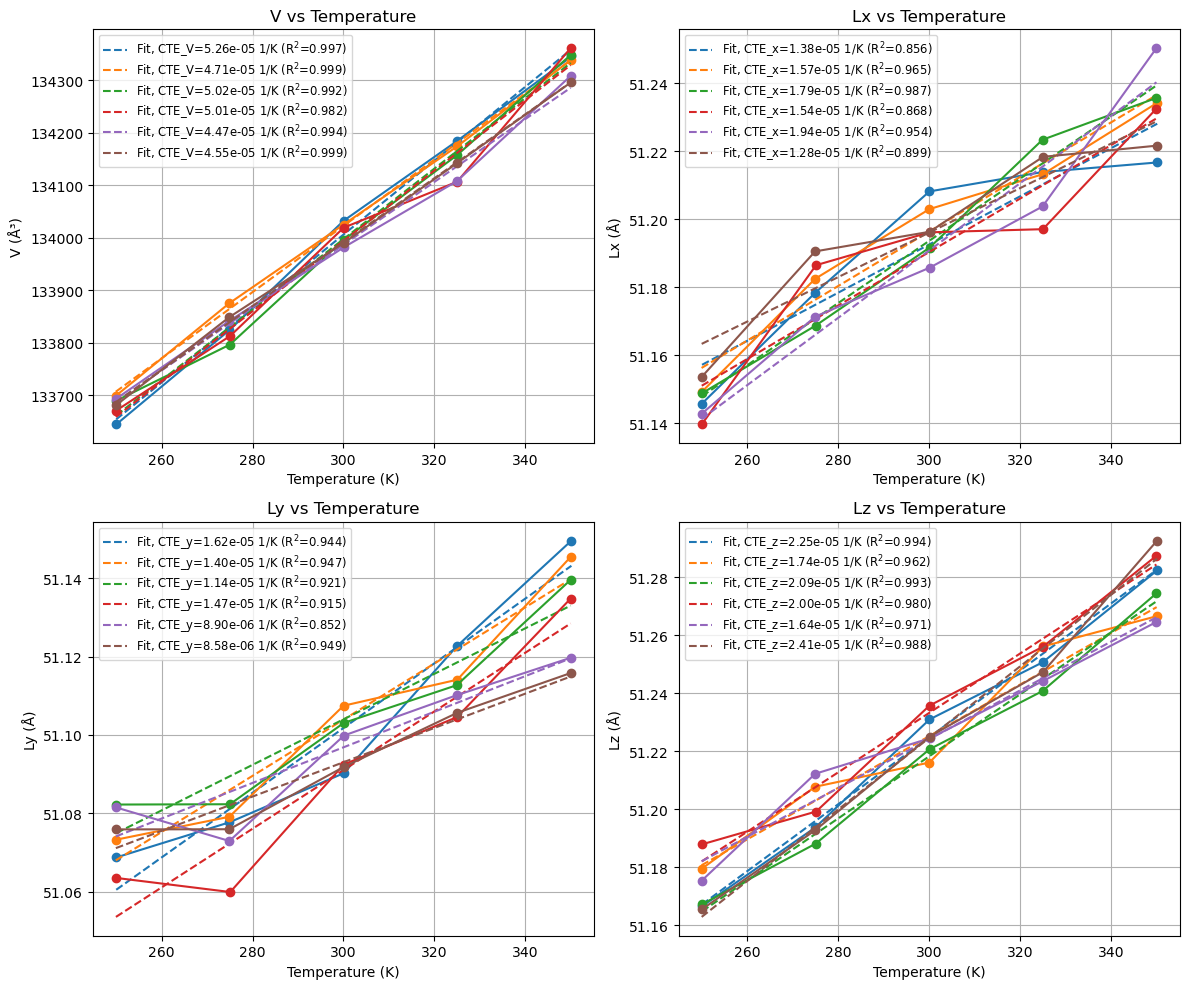

In [11]:
collected_CTE_V = []

# Set up the plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Loop over the provided files, read them, plot the data and compute the CTE.
for i in range(1, 7):
    with open(f"../notebooks/data/CTE_temperature_scan_run{i}.json", "r") as f:
        cte_results = json.load(f)

    # Loop over the V, Lx, Ly, Lz and show them in separate subplots
    for ax, datakey in zip([ax1, ax2, ax3, ax4], ["V", "Lx", "Ly", "Lz"]):
        # Fit the data to a linear function and compute the CTE based on the slope of the linear fit
        linear_fit_func, slope, R2 = linear_fit(cte_results["data"]["T"], cte_results["data"][datakey])
        ref_value = cte_results["data"][datakey][
            1
        ]  # If we are interested in the CTE at 300 K, we use the corresponding value at 300 K as prop0
        CTE = 1 / ref_value * slope
        if datakey == "V":
            collected_CTE_V.append(CTE)

        # Plot the data and the linear fit with the same color
        (plotline,) = ax.plot(
            cte_results["data"]["T"],
            cte_results["data"][datakey],
            marker="o",
            label=f"_{datakey}: {CTE:.2e} 1/K",
        )
        ax.plot(
            cte_results["data"]["T"],
            linear_fit_func(cte_results["data"]["T"]),
            color=plotline.get_color(),
            linestyle="--",
            label="Fit, CTE_{}={:.2e} 1/K".format(datakey.lstrip("L"), CTE) + r" (R$^2$" + "={:.3f})".format(R2),
        )

        # Axes labels, legend and grid
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel(f"{datakey} (Å³)" if datakey == "V" else f"{datakey} (Å)")
        ax.set_title("{} vs Temperature".format(datakey))
        ax.legend(
            fontsize="small",
            labelspacing=0.1,  # vertical spacing between entries
        )

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid()

# Use the data to compute a mean CTE_V and its uncertainty
# (uncertainty = standard deviation divided by sqrt(N-1), where N is the number of samples)
mean_CTE_V = np.mean(collected_CTE_V)
uncertainty_CTE_V = np.std(collected_CTE_V) / (np.sqrt(len(collected_CTE_V) - 1))
print(f"Mean CTE_V over the six runs: {mean_CTE_V:.2e} +/- {uncertainty_CTE_V:.2e} 1/K ")

fig.tight_layout()
plt.show()

Possible choices to tighten the results further include:
- Average over several workflow runs (use different seeds and/or initial configurations)
- Use larger system sizes (this reduces the thermodynamic noise and allows for better averaging)
- Increase the simulation time for each production run (allows for better averaging; but keep in mind the possibility of relaxation processes and drifting structural properties!)
- If the tested temperature range is wide, use more incremental temperature steps 

# b) Enthalpy-volume fluctuations approach
## Theory
As an alternative approach to the volume-temperature method described above, volume-enthalpy fluctuations can be used to compute CTEs directly from the output of a NPT simulation at only one temperature:
$$
\alpha = \frac{ \langle \delta V \ \delta( E + PV ) \rangle }{ k_\mathrm{B}T^2V }
$$
In this formula $\delta V$ and $\delta( E + PV )$ are volume and enthalpy fluctuations. The derivation and more details to the background can be found in textbooks on statistical mechanics, e.g. "Computer Simulation of Liquids" by M. P. Allen and D. J. Tildesley, 2017.


## Details on `cte_from_fluctuations_simulation` workflow
The most important input parameters for this workflow are:
- Temperature at which the simulations should be performed
- Number of initial equilibration steps (only done once) 
- Number of production steps that will be performed for each production run
- Minimum and maximum number of production runs that will be performed
- Convergence threshold for the uncertainty of the CTE value to decide when to stop the workflow

The general procedure of the workflow is as follows:

1. One short NVT simulation to equilibrate temperature for 10k steps (hardcoded)
2. One NPT equilibration run with user-specified number of steps to equilibrate the volume and cell dimensions at the given temperature
3. A series of NPT production runs. Each production is performed with the user-specified number of steps. The data of the current run is used to compute the CTE value based on the volume-enthalpy fluctuations. Whether the workflow continues with another production run or ends is decided after every production run based on the following criteria:
    
    i. If the user-specified minimum number of production runs is reached, the average CTE and its uncertainty are computed based on the CTEs from all production runs conducted so far. If the uncertainty is lower than the user-specified threshold, the workflow ends.

    ii. If the maximum number of production runs is reached, the workflow ends regardless of the uncertainty.
    
    iii. In all other cases, the next production run is performed. 


Conventionally, fluctuations are calculated as the difference between the instantaneous values at a given time step and the average value. Because we calculate CTEs for every production run separately, the average value would typically be considered as the average over the production run. However, relaxation processes of the glass during a production run can lead to slowly drifting properties. If not accounted for, this can lead to unexpected results because fluctuations would then be calculated based on a drifting property.

To circumvent this and filter out slowly-changing properties, we calculate fluctuations with respect to running averages instead of the average over the complete production run. In the current implementation of the `cte_from_fluctuations_simulation()` workflow this is done as follows: Data from 10 ps (5 ps before and 5 ps after the current time step) is used to compute an average $V$ and $(E + PV)$. Fluctuations are then calculated as the difference between the instantaneous value of the current time step and the running average.

## Caveats and things to consider
- If very large drifts are present in the system (e.g., initial glass structure has been generated with very fast quenching and CTE is directly calculated at elevated temperature) and the CTE of the system changes significantly over time, this approach can still lead to unexpected results. However, for typical glasses and simulation protocols this approach should yield robust results.
- A word of caution regarding the $(E + PV)$ term: Instead of the instantaneous values of $P$, one should rather use the pressure that *defines* the NPT ensemble (i.e., the user-defined target pressure) to compute the enthalpy. This is done in the current implementation of the workflow. It is slightly different from the enthalpy calculated directly by LAMMPS, which uses the instantaneous pressure at every timestep to compute the enthalpy. However, for solids and especially if low pressures are used, the differences between both approaches are typically negligible. For further details concerning this topic, see "Computer Simulation of Liquids" by M. P. Allen and D. J. Tildesley, 2017.
- How to handle the user-specified uncertainty threshold? Consider this: The volumetric CTE is approximately the sum of the linear CTEs along x, y, and z. If three variables x, y and z were uncorrelated and have known uncertainties sigma_x, sigma_y, and sigma_z, the uncertainty of the sum of them would be: sigma_V = sqrt( sigma_x^2 + sigma_y^2 + sigma_z^2 ). If we assume that the uncertainty criterion is reached at roughly the same time for all three variables, the uncertainty of the volumetric CTE can be approximated as sqrt(3)\*CTE_uncertainty_criterion. However, x, y and z are typically not uncorrelated. If calculated from the actual simulation data, the uncertainty of CTE_V is found to be approximately the same as the individual uncertainties of the linear CTEs. To be not too strict here, we keep the sqrt(3)\*CTE_uncertainty_criterion for CTE_V.

## Showcase: Enthalpy-volume fluctuations approach
We again rely on the same small SiO2 glass structure with 300 atoms from the example showcase above and reuse the structure and potential setup from the previous section. 
The majority of input parameters have the same meaning as for the `temperature_scan_simulation` workflow. However, because this workflow is designed to only perform simulations at a single temperature, the `temperature` input expects a single value instead of a list. The additional input parameters are:
- `min_production_runs`: The minimum number of production runs that will be performed. 
- `max_production_runs`: The maximum number of production runs that will be performed.
- `CTE_uncertainty_criterion`: The convergence threshold for the uncertainty of the CTE value to decide when to stop the workflow. The workflow will end if the uncertainty of the CTE value is lower than this threshold and the minimum number of production runs has been reached. If the maximum number of production runs is reached, the workflow will end regardless of the uncertainty.


In [12]:
### Running the CTE simulation locally with 4 cores for demonstration purposes (~1 min runtime)
server_kwargs = {"cores": 4}

with SingleNodeExecutor() as exe:
    cte_results_fluctuations_showcase = exe.submit(
        cte_from_fluctuations_simulation,
        structure=structure_glass_small,
        potential=generated_potential_Si_O,
        temperature=300,
        pressure=1e-4,
        timestep=1.0,
        equilibration_steps=20_000,
        production_steps=20_000,
        min_production_runs=2,
        max_production_runs=3,
        CTE_uncertainty_criterion=2e-6,
        n_dump=20_000,
        n_log=10,
        server_kwargs=server_kwargs,
        aniso=True,
        seed=12345,
    ).result()

/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lx. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Ly. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/Documents/Workflows/amorphouspy/.pixi/envs/default/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Lz. Returning un-normalized quantity
  warnings.warn(


Again, possible warnings concerning the unit conversion of quantity Lx/Ly/Lz can be ignored.

The output of this workflow is slightly different from the output of the `temperature_scan_simulation` workflow. It again holds `"data"` as one of its main keys, but additionally has a `"summary"` key. Under `"data"` we again store the `"run_index"` and number of simulation `"steps"` as well as the average structural and thermodynamic properties of every production run. Additionally, also the computed CTEs are stored under `"CTE_V"`, `"CTE_x"`, `"CTE_y"`, `"CTE_z"`

In [13]:
cte_results_fluctuations_showcase["data"]

{'run_index': array([1., 2., 3.]),
 'steps': array([20000., 20000., 20000.]),
 'T': array([298.10416885, 302.07136529, 300.68624434]),
 'E_tot': array([-5298.5176936 , -5298.2317941 , -5298.30855277]),
 'ptot': array([-0.00067641, -0.00050644, -0.00024314]),
 'pxx': array([-4.66991346e-06, -5.63313986e-04, -1.02289252e-04]),
 'pyy': array([-9.35080264e-04, -7.26438546e-04, -8.11448924e-05]),
 'pzz': array([-0.00108947, -0.00022957, -0.00054597]),
 'V': array([4476.46519115, 4471.79934308, 4472.61087656]),
 'Lx': array([16.2459893 , 16.23896443, 16.23387393]),
 'Ly': array([16.9715859, 16.9668664, 16.9662503]),
 'Lz': array([16.23563875, 16.23022375, 16.23885585]),
 'CTE_V': array([3.22890872e-05, 5.80223519e-05, 6.65185959e-05]),
 'CTE_x': array([2.44883862e-05, 2.20391732e-05, 3.64185313e-05]),
 'CTE_y': array([ 2.39797149e-05, -1.25729255e-05,  1.60726447e-05]),
 'CTE_z': array([-1.63167208e-05,  4.85731984e-05,  1.38839153e-05]),
 'structure_final': Atoms(symbols='O200Si100', pbc=Tr

The additionaly `"summary"` dictionary serves as a convenient way to obtain the averaged CTE values and their uncertainties without recomputing them again from the `"data"` dictionary. We list the final values for the CTEs under the keys `"CTE_V_mean"`, `"CTE_x_mean"`, `"CTE_y_mean"`, `"CTE_z_mean"` and their uncertainties under the keys `"CTE_V_uncertainty"`, `"CTE_x_uncertainty"`, `"CTE_y_uncertainty"`, `"CTE_z_uncertainty"`. Furthermore, we indicate whether the uncertainty criterion has been met under `"is_converged"` and also keep the user-specifed uncertainty threshold under `"convergence_criterion"`for reference. 

In [14]:
cte_results_fluctuations_showcase["summary"]

{'CTE_V_mean': 5.2276678309035614e-05,
 'CTE_x_mean': 2.7648696926582105e-05,
 'CTE_y_mean': 9.159811378290218e-06,
 'CTE_z_mean': 1.538013098730686e-05,
 'CTE_V_uncertainty': 1.0290357795848764e-05,
 'CTE_x_uncertainty': 4.441552199615817e-06,
 'CTE_y_uncertainty': 1.1103517890128721e-05,
 'CTE_z_uncertainty': 1.874703886579092e-05,
 'is_converged': 'False',
 'convergence_criterion': 2e-06}

Because this showcase was run on a small system with rather short production runs (i.e., few data points to compute the fluctuations) and also with few production runs, the uncertainty of the CTE values is quite high and will most likely never been met in such a setup. We will see in the following, how this may look like for a more reasonable simulation setup.

## Analysis of a more realistic simulation.
We use the same input structure and potential as has been used for the more realistic simulation of the temperature-volume approach (Si-Na-O glass, ~10k atoms). To avoid lengthy simulations, we provide pre-computed results obtained from 4 simulations. These have been executed with different `production_steps` to illustrate how this can affect the results. We tried 50, 100, 150 and 200 ps prduction runs and allowed up to 200 production runs. The uncertainty threshold was set to 1e-6 1/K. 

If you want to run the simulations yourself, change the `SKIP_SIMULATION` flag to `False` and make sure to adjust the `production_steps` input parameter to the desired values. Note that we have again removed the `structure_final` to reduce file size and be able to store the output as json files.

In [15]:
SKIP_SIMULATION = True

if SKIP_SIMULATION:
    print("Simulation skipped to save time. We will use previously generated results for the analysis part.")
else:
    server_kwargs = {"cores": 4}
    with SingleNodeExecutor() as exe:
        cte_results_fluctuations = exe.submit(
            cte_from_fluctuations_simulation,
            structure=structure_glass_Si_Na_O,
            potential=generated_potential_Si_Na_O,
            temperature=300,
            pressure=1e-4,
            timestep=1.0,
            equilibration_steps=500_000,
            production_steps=200_000,  # we checked 50, 100, 150 and 200 ps here
            min_production_runs=10,
            max_production_runs=200,
            CTE_uncertainty_criterion=1e-6,
            n_dump=200_000,
            n_log=5,
            server_kwargs=server_kwargs,
            aniso=True,
            seed=12345,
        ).result()

Simulation skipped to save time. We will use previously generated results for the analysis part.


Let us first inspect the summary of the results. To this end, we collect the individual summaries of the 4 simulation and compile them in a pandas DataFrame for a more comprehensive overview. We also add the number of production steps to keep track of which data belongs to which simulation. 

We find that the 200 production runs with 50 ps and 100 ps were not enough to reach converged CTEs, but the reached uncertainties are already close to the given uncertainty criterion of 1e-6 1/K. The remaining runs with 150 ps and 200 ps reached the convergence criterion successfully.

In [16]:
collected_summaries = []
for steps in [50, 100, 150, 200]:
    summary = {"production_steps": steps * 1000}
    with open(f"../notebooks/data/CTE_fluctuations_{steps}ps_production_runs.json", "r") as f:
        cte_results_longer_sim = json.load(f)
    summary.update(cte_results_longer_sim["summary"])
    collected_summaries.append(summary)
df = pd.DataFrame(collected_summaries)

# Reorder one of the columns for better visualization
col = df.pop("is_converged")
df.insert(1, "is_converged", col)
df

,production_steps,is_converged,CTE_V_mean,CTE_V_uncertainty,CTE_x_mean,CTE_x_uncertainty,CTE_y_mean,CTE_y_uncertainty,CTE_z_mean,CTE_z_uncertainty,convergence_criterion
0,50000,False,4.34e-05,1.66e-06,1.53e-05,1.54e-06,1.41e-05,1.59e-06,1.40e-05,1.48e-06,1.00e-06
1,100000,False,4.56e-05,1.21e-06,1.55e-05,1.15e-06,1.49e-05,1.12e-06,1.51e-05,1.21e-06,1.00e-06
2,150000,True,4.52e-05,9.11e-07,1.74e-05,9.23e-07,1.34e-05,9.96e-07,1.43e-05,8.83e-07,1.00e-06
3,200000,True,4.51e-05,1.03e-06,1.56e-05,9.95e-07,1.35e-05,8.85e-07,1.60e-05,9.23e-07,1.00e-06


Let us now inspect the results more closely and visualize how the uncertainty develops with the number of production runs for the different production times. To this end, we need to work with the data stored under the `"data"` key of the workflow output. Let us first define small helper functions that will useful for the analysis:

In [17]:
def mean_and_uncertainty(values):
    if len(values) < 2:
        return np.mean(values), np.nan
    else:
        return np.mean(values), np.std(values, ddof=1) / np.sqrt(len(values))


def cumulative_mean_and_uncertainty(values):
    means = []
    uncertainties = []
    for index in range(len(values)):
        subset = values[: index + 1]
        m, u = mean_and_uncertainty(subset)
        means.append(m)
        uncertainties.append(u)
    return means, uncertainties

We plot the average CTEs as lines with the corresponding uncertainty as shaded area. From top to bottom we show the results for the 50, 100, 150 and 200 ps production runs. The left column of plots show the linear CTEs along x, y and z, and the right column shows the volumetric CTE. For the volumetric CTE we also show individual CTE values that are obtained from each production run as gray crosses.

The workflow with a simulation time of 50 ps for each production run performed 200 production runs.
The minimal and maximal CTE_V values from individual production runs are -1.56e-05 1/K and 1.06e-04 1/K, respectively.
The workflow with a simulation time of 100 ps for each production run performed 200 production runs.
The minimal and maximal CTE_V values from individual production runs are -3.44e-06 1/K and 1.01e-04 1/K, respectively.
The workflow with a simulation time of 150 ps for each production run performed 185 production runs.
The minimal and maximal CTE_V values from individual production runs are 1.63e-05 1/K and 8.13e-05 1/K, respectively.
The workflow with a simulation time of 200 ps for each production run performed 148 production runs.
The minimal and maximal CTE_V values from individual production runs are 1.34e-05 1/K and 8.39e-05 1/K, respectively.


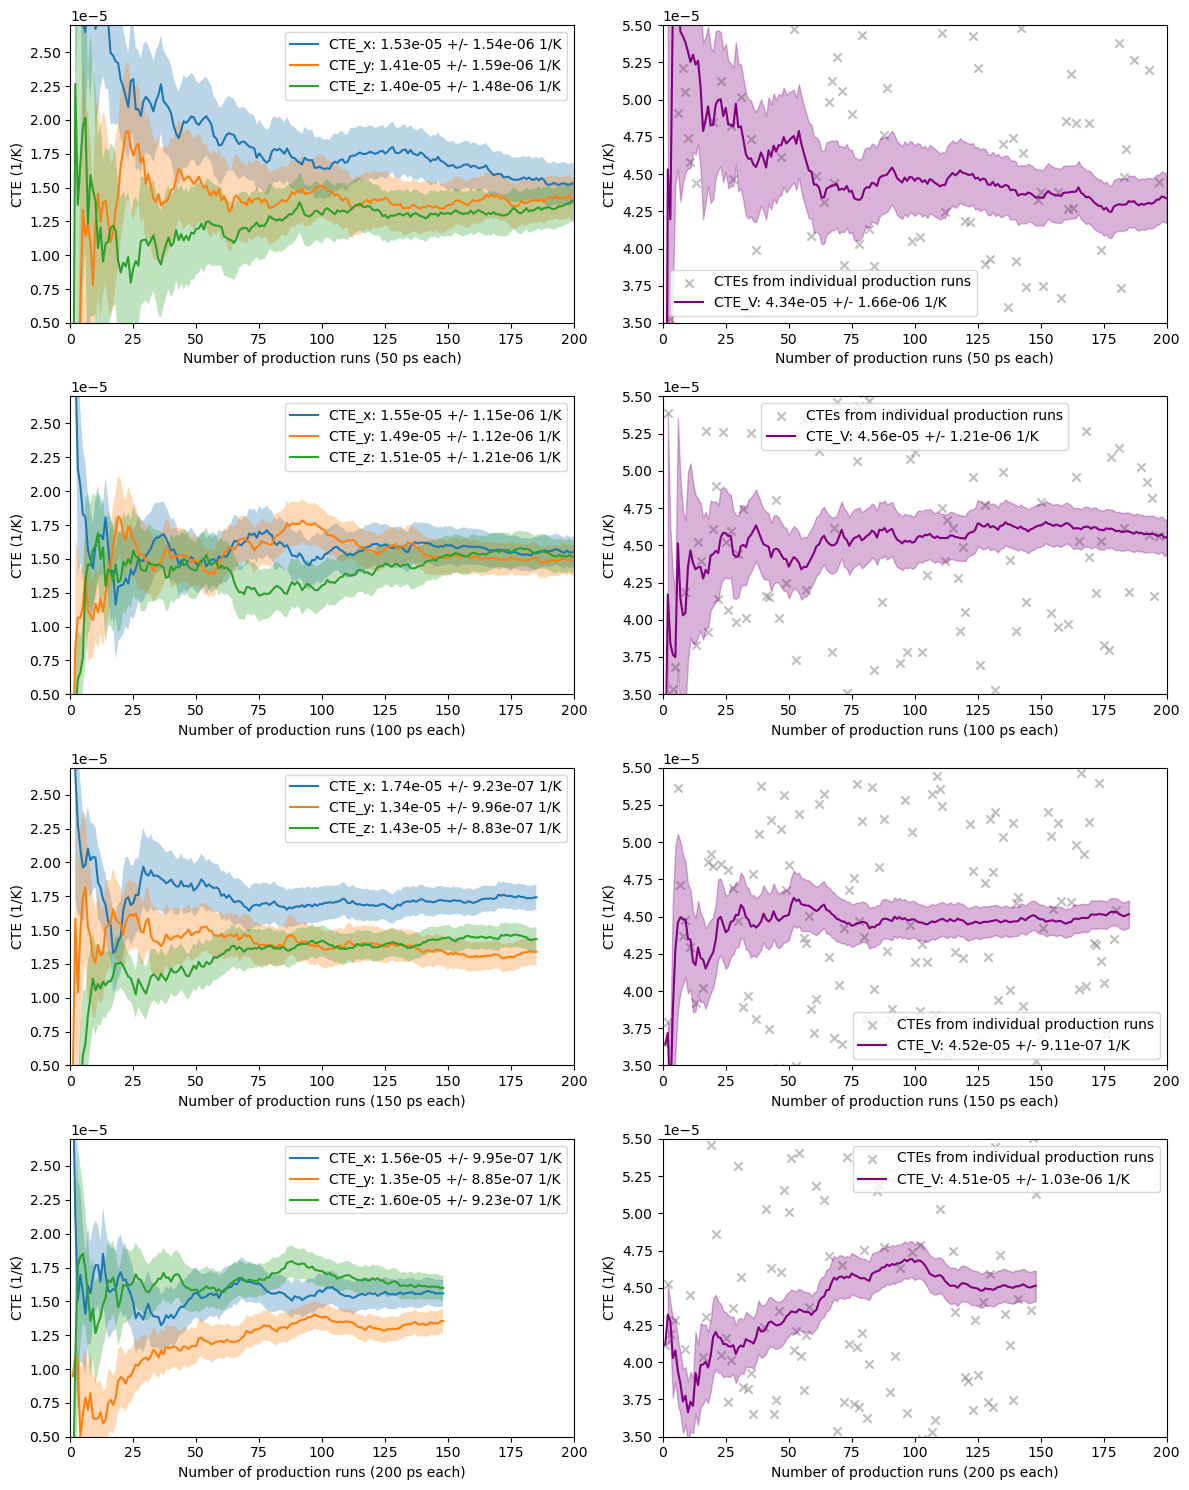

In [18]:
# Plotting the results
fig, ((ax1, ax1V), (ax2, ax2V), (ax3, ax3V), (ax4, ax4V)) = plt.subplots(4, 2, figsize=(12, 15))


# Volume plotting
for ax, steps in zip([ax1V, ax2V, ax3V, ax4V], [50, 100, 150, 200]):
    with open(f"../notebooks/data/CTE_fluctuations_{steps}ps_production_runs.json", "r") as f:
        cte_results_longer_sim = json.load(f)

    means, uncertainties = cumulative_mean_and_uncertainty(cte_results_longer_sim["data"]["CTE_V"])
    print(
        f"The workflow with a simulation time of {steps} ps for each production run performed {len(means)} production runs."
    )
    print(
        f"The minimal and maximal CTE_V values from individual production runs are {np.min(cte_results_longer_sim['data']['CTE_V']):.2e} 1/K and {np.max(cte_results_longer_sim['data']['CTE_V']):.2e} 1/K, respectively."
    )

    # plot actual data points of every run
    ax.scatter(
        cte_results_longer_sim["data"]["run_index"],
        cte_results_longer_sim["data"]["CTE_V"],
        marker="x",
        alpha=0.5,
        color="gray",
        label="CTEs from individual production runs",
    )
    # plot the mean value
    ax.plot(
        cte_results_longer_sim["data"]["run_index"],
        means,
        color="purple",
        label=f"CTE_V: {means[-1]:.2e} +/- {uncertainties[-1]:.2e} 1/K",
    )
    # plot uncertainty bands as shaded area
    ax.fill_between(
        cte_results_longer_sim["data"]["run_index"],
        np.array(means) - np.array(uncertainties),
        np.array(means) + np.array(uncertainties),
        color="purple",
        alpha=0.3,
    )

    ax.set_xlim(0, 200)
    ax.set_ylim(3.5e-5, 5.5e-5)
    ax.set_xlabel(f"Number of production runs ({steps} ps each)")
    ax.set_ylabel("CTE (1/K)")
    ax.legend()


# Components plotting
for ax, steps in zip([ax1, ax2, ax3, ax4], [50, 100, 150, 200]):
    with open(f"../notebooks/data/CTE_fluctuations_{steps}ps_production_runs.json", "r") as f:
        cte_results_longer_sim = json.load(f)

    for cte_key in ["CTE_x", "CTE_y", "CTE_z"]:
        means, uncertainties = cumulative_mean_and_uncertainty(cte_results_longer_sim["data"][cte_key])

        # plot actual data points of every run
        # ax.scatter(
        #    cte_results_longer_sim['data']['run_index'],
        #    cte_results_longer_sim['data'][cte_key],
        #    marker="x",
        #    alpha=0.5,
        #    label=f"{cte_key} data",
        # )
        # plot the mean value
        ax.plot(
            cte_results_longer_sim["data"]["run_index"],
            means,
            label=f"{cte_key}: {means[-1]:.2e} +/- {uncertainties[-1]:.2e} 1/K",
        )
        # plot uncertainty bands as shaded area
        ax.fill_between(
            cte_results_longer_sim["data"]["run_index"],
            np.array(means) - np.array(uncertainties),
            np.array(means) + np.array(uncertainties),
            alpha=0.3,
        )

    ax.legend()
    ax.set_xlim(0, 200)
    ax.set_ylim(0.5e-5, 2.7e-5)
    ax.set_xlabel(f"Number of production runs ({steps} ps each)")
    ax.set_ylabel("CTE (1/K)")


fig.tight_layout()

There are several interesting conclusions from the plots and the output we printed above. First, all approaches lead to similar CTEs around 4.5e-5/K. Only the workflow with 50 ps production run length reached a considerably lower value of 4.3e-5/K (but it is also the one farthest from converce). 

Second, the CTE values from individual production runs show a considerable scatter. Looking at CTE_V values we find that when using 50 ps production runs, the CTE_V value scatters between -1.56e-05/K and 1.06e-04/K. Unsurprisingly, we find that the longer the production runs, the less scatter is observed. For 200 ps the scatter is reduced to a range between 1.34e-05/K and 8.39e-05/K. However, using longer production runs is not necessarily the best way to reach converged results faster. This is because every production run only contributes one CTE value - but the uncertainty calculation tightens with the number of CTE values. Therefore, one should target a reasonable compromise between the length of production runs and the number of production runs.

Let us inspect this for the 150 ps and 200 ps case: Excluding the initial equilibration time, the workflow using 150 ps production runs required 185 runs to converge, resulting in an overall computational time of 150 ps \* 185 runs = 27,750 ps. The workflow using 200 ps production runs required only 148 runs to converge, resulting in an overall computational time of 200 ps \* 148 runs = 29,600 ps. The similar overall computational time for the 150 ps and 200 ps case indicates that the compromise may not be a very strict one. As long as the settings are chosen reasonable, similar overall computational time and accuracy of the results can be expected.

# Final comparison and words

Finally, let us compare the results obtained from the two different approaches for the case of the Si-Na-O system considering only the CTE_V. If averaged over the six runs shown further above, the temperature-volume approach achieved a value of:

4.84e-05 +/- 1.26e-06 1/K

The volume-enthalpy fluctuations-based workflow relying on 200 ps production runs achieved a value of:

4.51e-05 +/- 1.03e-06 1/K

The similarity of both approaches let's us conclude that both approaches are valid to compute the CTE and yield similar results. The temperature-volume approach is more straightforward and visualization of the structural changes are easy to grasp. However, it requires an additional post-processing step and a user decision how the structural data should be fitted to obtain the CTE. Furthermore, averaging over multiple runs is needed to assess the robustness of the statistics and to estimate uncertainties. 

On the other hand, the enthalpy-volume fluctuations approach comes with a more complex workflow and the underlying theory is less intuitive. It allows to compute CTEs directly from the output of NPT simulations at only one temperature, which can be an advantage or disadvantage depending on the case. If convergence is achieved within the workflow, it does not require any post-processing step and provides a built-in way to estimate uncertainties. Even if not converged, the results can still provide useful insights. However, compared to the temperature-volume approach, the computational costs of the fluctuations-based approach are most likely higher.